<a href="https://colab.research.google.com/github/expe-rience/AIML-Case-Study/blob/main/CO2_Emission_Case_Study_with_RASSO_Ridge-K-Fold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **CO₂ Emission Case Study**
### AIML Case Study — Global Automotive Council

| Criterion | Where it is addressed |
|---|---|
| 1. Problem understanding & context | Section 1 |
| 2. Data exploration & preparation | Sections 2, 3, 5 |
| 3. Analytical depth & visualization | Section 4 |
| 4. Model development & explanation | Sections 5, 6 |
| 5. Model evaluation & interpretation | Section 7 |
| 6. Business insight & recommendations | Section 8 |

**Case-study question map:** Q1 to Section 1–2 · Q2 to Section 3 · Q3 to Q3 correlation analysis–4.2 · Q4 to Q4 visual analysis · Q5 to Q5 comparison analysis · Q6 to Section 4.5 · Q7 to Section 5 · Q8 to the model-building section · Q9 to Section 7 · Q10 to Section 8


---
## 1. Problem Understanding & Business Context (Q1)

**Business problem.** The Global Automotive Council wants to know *what drives vehicle CO₂ emissions* and *which design and emission-reduction levers reduce them most*. Transport is a major source of greenhouse-gas emissions, so knowing which vehicle characteristics matter most lets regulators target efficiency standards, fleet-mix incentives and design guidance where they have the greatest effect.

**Analytical plan.**
1. Check data quality (missing values, duplicates, types) and the behaviour of the target variable.
2. Detect outliers and decide, with justification, how to treat them.
3. Explore relationships (correlation, scatter plots, category comparisons) and diagnose **multicollinearity** (VIF).
4. Build a preprocessing + model pipeline (one-hot encoding, scaling) and compare two scenarios:
   - **Model A — Specification-only:** what can be predicted from design characteristics *before* fuel consumption is measured?
   - **Model B — Specification + combined fuel consumption:** how much does a measured efficiency figure add?
5. Compare ordinary linear regression with regularized (Ridge / Lasso) models using cross-validation, evaluate with several metrics, inspect residuals and turn the results into recommendations.

**Dataset.** [CO2_Emissions.csv](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/208/original/CO2_Emissions.csv?1760012266) · [Dataset description](https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/211/original/Dataset_Description.pdf?1760012364)

| Feature group | Columns |
|---|---|
| Vehicle identity | Make, Model, Vehicle Class |
| Engine specs | Engine Size (L), Cylinders, Transmission |
| Fuel profile | Fuel Type (X, Z, D, E, N) |
| Consumption metrics | City, Highway, Combined (L/100 km) and Combined (mpg) |
| Target | CO₂ Emissions (g/km) |

---
## 2. Setup & Data Loading (Q1)

In [ ]:
import os
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

In [ ]:
DATA_URL = ("https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/158/208/"
            "original/CO2_Emissions.csv?1760012266")
DATA_PATH = "CO2_Emissions.csv"

if not os.path.exists(DATA_PATH):
    try:
        req = urllib.request.Request(DATA_URL, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as resp, open(DATA_PATH, "wb") as f:
            f.write(resp.read())
    except Exception as e:
        raise SystemExit(f"Download failed ({e}). Download the CSV from the link above "
                         f"and save it next to this notebook as '{DATA_PATH}'.")

cars = pd.read_csv(DATA_PATH)
TARGET = "CO2 Emissions(g/km)"
CONSUMPTION_COLS = [c for c in cars.columns if c.startswith("Fuel Consumption")]
COMB = "Fuel Consumption Comb (L/100 km)"
FUEL_TYPES = {"X": "Regular gasoline", "Z": "Premium gasoline", "D": "Diesel",
              "E": "Ethanol (E85)", "N": "Natural gas"}

print("Shape:", cars.shape)
cars.head()

Shape: (7385, 12)


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


### Observation — Q1
- The dataset holds **7,385 vehicle records and 12 variables**: manufacturer, model, vehicle class, engine characteristics, transmission, fuel type, four fuel-consumption measures and CO₂ emissions.
- `CO₂ Emissions(g/km)` is the **target variable**.
- **Numerical predictors:** engine size, cylinders and the consumption measures. **Categorical predictors:** make, model, vehicle class, transmission and fuel type.
- Working hypothesis: engine characteristics and fuel consumption will be strongly associated with CO₂. This is tested below rather than assumed.

---
## 3. Data Quality & Preparation (Q2)
### 3.1 Structure and missing values

In [ ]:
print("Shape:", cars.shape)
print()
cars.info()
print("\nMissing values per column:")
display(cars.isnull().sum().to_frame("Missing"))

Shape: (7385, 12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   

,Missing
Make,0
Model,0
Vehicle Class,0
Engine Size(L),0
Cylinders,0
Transmission,0
Fuel Type,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0


### Observation There are 7,385 rows and 12 columns (7 numerical, 5 text/categorical) and **no missing values**, so no imputation is required. Categorical columns will need encoding before regression.

### 3.2 Duplicate records

In [ ]:
n_dup = cars.duplicated().sum()
print("Exact duplicate rows:", n_dup)

print("\nMost repeated records:")
display(cars[cars.duplicated(keep=False)]
        .groupby(list(cars.columns)).size()
        .sort_values(ascending=False).head(10).reset_index(name="Count"))

cars_no_duplicates = cars.drop_duplicates().reset_index(drop=True)
print("\nRows before:", len(cars), "| after:", len(cars_no_duplicates),
      "| removed:", len(cars) - len(cars_no_duplicates))

# Does removing duplicates change the picture?
def summarise(df):
    corr = df.select_dtypes(include=np.number).corr()[TARGET]
    return {"Rows": len(df), "Mean CO2": df[TARGET].mean(), "Median CO2": df[TARGET].median(),
            "Corr(Engine Size)": corr["Engine Size(L)"], "Corr(Cylinders)": corr["Cylinders"],
            "Corr(Comb L/100km)": corr[COMB]}
display(pd.DataFrame({"Original": summarise(cars), "De-duplicated": summarise(cars_no_duplicates)}).T.round(3))

Exact duplicate rows: 1103

Most repeated records:


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Count
0,LEXUS,GS F,COMPACT,5.0,8,AS8,Z,14.9,9.7,12.5,23,293,5
1,NISSAN,370Z,TWO-SEATER,3.7,6,AS7,Z,12.6,9.3,11.1,25,261,4
2,MITSUBISHI,RVR 4WD,SUV - SMALL,2.0,4,AV6,X,10.1,8.2,9.2,31,213,4
3,TOYOTA,86,MINICOMPACT,2.0,4,AS6,Z,9.9,7.3,8.7,32,204,4
4,CHRYSLER,300,FULL-SIZE,3.6,6,A8,X,12.4,7.8,10.3,27,242,4
5,LEXUS,RX 450h AWD,SUV - STANDARD,3.5,6,AV6,Z,7.5,8.4,7.9,36,185,4
6,SUBARU,BRZ,MINICOMPACT,2.0,4,AS6,Z,9.7,7.2,8.6,33,200,4
7,LEXUS,RC F,SUBCOMPACT,5.0,8,AS8,Z,15.2,9.5,12.6,22,289,4
8,CHRYSLER,300 AWD,FULL-SIZE,3.6,6,A8,X,12.8,8.7,11.0,26,258,4
9,LEXUS,NX 300h AWD,SUV - SMALL,2.5,4,AV6,X,7.2,7.9,7.5,38,176,4



Rows before: 7385 | after: 6282 | removed: 1103


,Rows,Mean CO2,Median CO2,Corr(Engine Size),Corr(Cylinders),Corr(Comb L/100km)
Original,7385.0,250.585,246.0,0.851,0.833,0.918
De-duplicated,6282.0,251.158,246.0,0.855,0.835,0.917


### Observation — Q2
- There are **1,103 exact duplicate rows** (7,385 to 6,282 after removal).
- Identical rows would give some vehicle configurations extra weight in training and could leak into the test set, inflating scores.
- Mean CO₂ moves only slightly (250.58 to 251.16 g/km) and the correlations are almost unchanged, so the duplicates do not distort the overall relationships.
- **Decision:** model on `cars_no_duplicates` (identical records add no information); keep `cars` for reference.

### 3.3 Descriptive statistics

In [ ]:
display(cars_no_duplicates.describe().T.round(2))
print("\nCategorical columns:")
display(cars_no_duplicates.describe(include="O").T)
print("\nFuel type codes:", FUEL_TYPES)

,count,mean,std,min,25%,50%,75%,max
Engine Size(L),6282.0,3.16,1.37,0.9,2.0,3.0,3.7,8.4
Cylinders,6282.0,5.62,1.85,3.0,4.0,6.0,6.0,16.0
Fuel Consumption City (L/100 km),6282.0,12.61,3.55,4.2,10.1,12.1,14.7,30.6
Fuel Consumption Hwy (L/100 km),6282.0,9.07,2.28,4.0,7.5,8.7,10.3,20.6
Fuel Consumption Comb (L/100 km),6282.0,11.02,2.95,4.1,8.9,10.6,12.7,26.1
Fuel Consumption Comb (mpg),6282.0,27.41,7.25,11.0,22.0,27.0,32.0,69.0
CO2 Emissions(g/km),6282.0,251.16,59.29,96.0,208.0,246.0,289.0,522.0



Categorical columns:


,count,unique,top,freq
Make,6282,42,FORD,577
Model,6282,2053,F-150 FFV,32
Vehicle Class,6282,16,SUV - SMALL,1006
Transmission,6282,27,AS6,1139
Fuel Type,6282,5,X,3039



Fuel type codes: {'X': 'Regular gasoline', 'Z': 'Premium gasoline', 'D': 'Diesel', 'E': 'Ethanol (E85)', 'N': 'Natural gas'}


### Observation — Q2
- Engine size ranges from **0.9 to 8.4 L**, cylinders from **3 to 16**, combined consumption from **4.1 to 26.1 L/100 km** and CO₂ from **96 to 522 g/km** — plenty of spread to learn from.
- There are **42 makes, 2,053 models, 16 vehicle classes, 27 transmission types and 5 fuel types**.
- `Model` (2,053 levels) is close to an identifier; one-hot encoding it would create thousands of sparse columns and make the model uninterpretable. `Make` (42 levels) largely repeats what vehicle class and engine already describe. Both are excluded from the model and kept only for diagnostics.

### 3.4 Distribution of the target variable

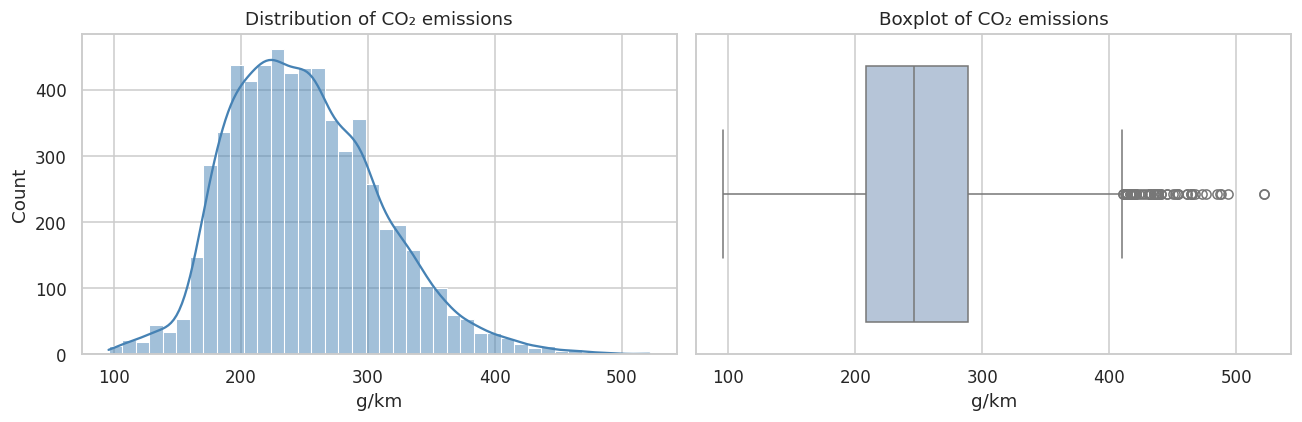

Mean = 251.2 | Median = 246.0 | Std = 59.3
Skewness = 0.56 | Excess kurtosis = 0.44
Reading: moderately right-skewed


In [ ]:
y_all = cars_no_duplicates[TARGET]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_all, kde=True, bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of CO₂ emissions"); axes[0].set_xlabel("g/km")
sns.boxplot(x=y_all, ax=axes[1], color="lightsteelblue")
axes[1].set_title("Boxplot of CO₂ emissions"); axes[1].set_xlabel("g/km")
plt.tight_layout(); plt.show()

skew, kurt = y_all.skew(), y_all.kurt()
print(f"Mean = {y_all.mean():.1f} | Median = {y_all.median():.1f} | Std = {y_all.std():.1f}")
print(f"Skewness = {skew:.2f} | Excess kurtosis = {kurt:.2f}")
print("Reading:", "roughly symmetric" if abs(skew) < 0.5 else
      ("moderately right-skewed" if skew < 1 else "strongly right-skewed"))

### Observation — Q2.4 The histogram and the printed skewness/kurtosis show how far the target departs from a normal shape (a mean above the median indicates a right tail from high-emission vehicles). Linear regression does not require a *normal target*, only reasonably well-behaved residuals, so the target is **not transformed**; this choice is validated with the residual plots in Q9 residual analysis.

### 3.5 Outlier detection and treatment

In [ ]:
num_cols_all = cars_no_duplicates.select_dtypes(include=np.number).columns
rows, masks = [], {}
for c in num_cols_all:
    s = cars_no_duplicates[c]
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    masks[c] = (s < lo) | (s > hi)
    rows.append({"Column": c, "Lower fence": lo, "Upper fence": hi,
                 "Outliers": int(masks[c].sum()), "% of rows": 100 * masks[c].mean()})
display(pd.DataFrame(rows).round(2))

co2_out = cars_no_duplicates[masks[TARGET]]
print(f"\nCO₂ outliers: {len(co2_out)} rows")
print("\nBy vehicle class:"); display(co2_out["Vehicle Class"].value_counts().head(6).to_frame("Count"))
print("By fuel type:");      display(co2_out["Fuel Type"].value_counts().to_frame("Count"))

,Column,Lower fence,Upper fence,Outliers,% of rows
0,Engine Size(L),-0.55,6.25,121,1.93
1,Cylinders,1.00,9.00,177,2.82
2,Fuel Consumption City (L/100 km),3.20,21.60,116,1.85
3,Fuel Consumption Hwy (L/100 km),3.30,14.50,150,2.39
4,Fuel Consumption Comb (L/100 km),3.20,18.40,115,1.83
5,Fuel Consumption Comb (mpg),7.00,47.00,95,1.51
6,CO2 Emissions(g/km),86.50,410.50,74,1.18



CO₂ outliers: 74 rows

By vehicle class:


,Count
Vehicle Class,
VAN - PASSENGER,38
TWO-SEATER,20
SUV - STANDARD,11
MID-SIZE,4
PICKUP TRUCK - STANDARD,1


By fuel type:


,Count
Fuel Type,
Z,35
X,31
E,8


### Observation — Q2: Outliers
- The IQR rule flags a small share of rows, concentrated in large-engine, high-cylinder vehicle classes (see the tables above).
- These are **genuine rare vehicles** (high-performance, large SUVs, vans and pickups), not data-entry errors: their CO₂ is consistent with their engine size and fuel consumption.
- These vehicles are exactly the ones a decision-maker most needs to understand; dropping them would hide the high-emission end of the fleet, and capping would distort real values.
- Their influence is checked afterwards in the residual analysis (Q9 error analysis). If the model fails on them, this is reported rather than hidden.

---
## 4. Exploratory Analysis & Visualization (Q3–Q6)
### 4.1 Correlation with the target (Q3)

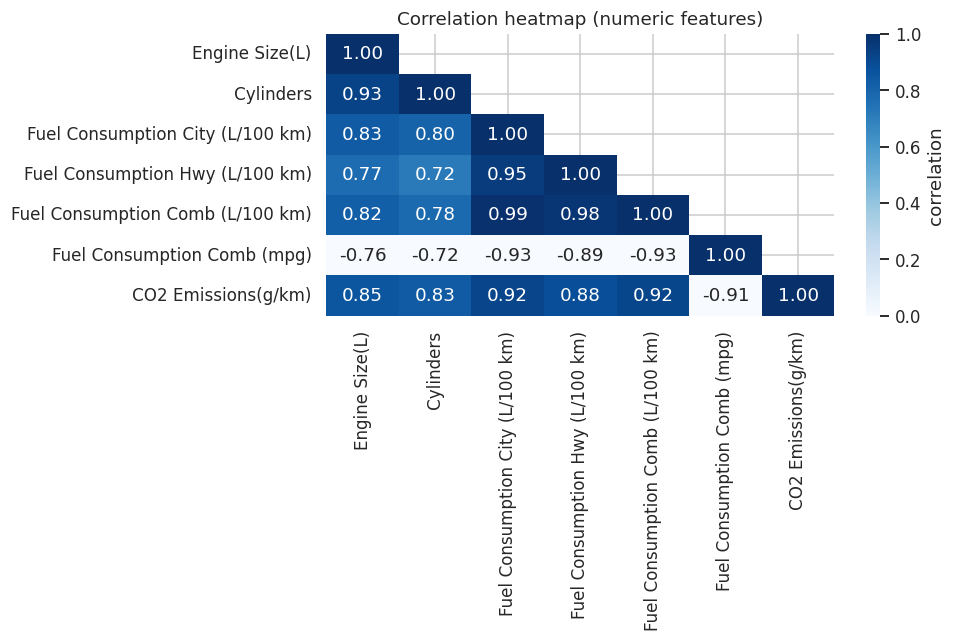

Correlation with CO₂ emissions:


,Pearson r
Fuel Consumption City (L/100 km),0.919
Fuel Consumption Comb (L/100 km),0.917
Fuel Consumption Hwy (L/100 km),0.883
Engine Size(L),0.855
Cylinders,0.835
Fuel Consumption Comb (mpg),-0.907


In [ ]:
eda = cars_no_duplicates.copy()
numeric = eda.select_dtypes(include=np.number)
corr = numeric.corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), cmap="Blues",
            annot=True, fmt=".2f", vmin=0, vmax=1, cbar_kws={"label": "correlation"})
plt.title("Correlation heatmap (numeric features)"); plt.tight_layout(); plt.show()

print("Correlation with CO₂ emissions:")
display(corr[TARGET].drop(TARGET).sort_values(ascending=False).to_frame("Pearson r").round(3))

**Observation — Q3.**
- **Fuel consumption** (combined about 0.92 with CO₂) has the strongest linear relationship with emissions, followed by **engine size** and **cylinders**.
- The four consumption columns are almost perfectly correlated with *each other*. Including all of them in one linear model would be a multicollinearity trap to diagnosed formally next.
- `Fuel Consumption Comb (mpg)` is **negatively** correlated with CO₂: higher mpg means lower consumption. It is the mathematical inverse of L/100 km, not independent information.
- Correlation is only a linear, one-variable-at-a-time view; the model-based importance in the model interpretation section checks whether the two views agree.

### 4.2 Multicollinearity diagnosis with VIF
The Variance Inflation Factor measures how well one predictor can be reconstructed from the others: `VIF = 1 / (1 − R²)`. Rule of thumb: > 5 = concerning, > 10 = severe.

In [ ]:
def vif_table(df, cols):
    X = add_constant(df[cols].astype(float))
    return (pd.DataFrame({"Feature": cols,
                          "VIF": [variance_inflation_factor(X.values, i + 1) for i in range(len(cols))]})
            .sort_values("VIF", ascending=False).reset_index(drop=True))

numeric_predictors = [c for c in numeric.columns if c != TARGET]
print("VIF — all numeric predictors")
display(vif_table(eda, numeric_predictors).round(1))

# The mpg column is (almost) the exact inverse of L/100 km: their product is ~constant
prod = eda[COMB] * eda["Fuel Consumption Comb (mpg)"]
print(f"Comb (L/100km) × Comb (mpg): min={prod.min():.1f}, median={prod.median():.1f}, max={prod.max():.1f}")

reduced = ["Engine Size(L)", "Cylinders", COMB]
print("\nVIF — after keeping only combined L/100 km")
display(vif_table(eda, reduced).round(1))

VIF — all numeric predictors


,Feature,VIF
0,Fuel Consumption Comb (L/100 km),5045.3
1,Fuel Consumption City (L/100 km),2225.3
2,Fuel Consumption Hwy (L/100 km),623.6
3,Engine Size(L),8.8
4,Cylinders,7.7
5,Fuel Consumption Comb (mpg),7.3


Comb (L/100km) × Comb (mpg): min=271.2, median=282.1, max=292.6

VIF — after keeping only combined L/100 km


,Feature,VIF
0,Engine Size(L),8.8
1,Cylinders,7.3
2,Fuel Consumption Comb (L/100 km),3.1


### Observation — Q3
- With City, Highway, Combined (L/100 km) and Combined (mpg) all present, the VIFs are extremely high: these columns measure one underlying signal in different contexts/units. `mpg × L/100 km` is almost a constant, confirming the inverse relationship.
- **City** and **Highway** are the two components blended into **Combined**, and **mpg** is its reciprocal, so they add no independent information.
- **Decision:** keep **only `Fuel Consumption Comb (L/100 km)`** (the standard headline efficiency figure, directly proportional to fuel burned) and drop City, Highway and mpg.
- After the drop, the extreme VIFs disappear (second table). Engine size and cylinders remain the most related pair, so some residual multicollinearity persists — which is why regularized models (Ridge/Lasso) are also tested in the model-building section.

### 4.3 Emissions versus numerical features (Q4)

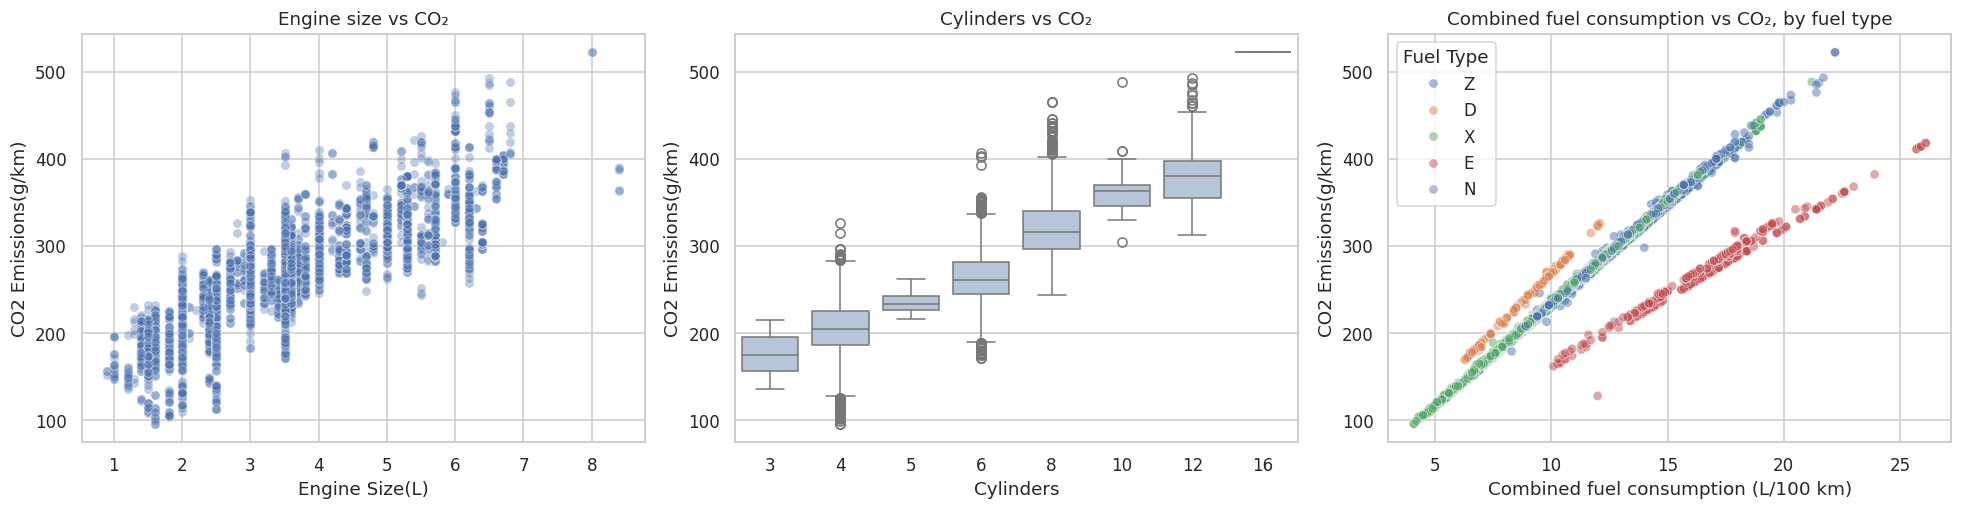

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
sns.scatterplot(data=eda, x="Engine Size(L)", y=TARGET, alpha=0.35, ax=axes[0])
axes[0].set_title("Engine size vs CO₂")
sns.boxplot(data=eda, x="Cylinders", y=TARGET, ax=axes[1], color="lightsteelblue")
axes[1].set_title("Cylinders vs CO₂")
sns.scatterplot(data=eda, x=COMB, y=TARGET, hue="Fuel Type", alpha=0.5, ax=axes[2])
axes[2].set_title("Combined fuel consumption vs CO₂, by fuel type")
axes[2].set_xlabel("Combined fuel consumption (L/100 km)")
plt.tight_layout(); plt.show()

**Observation — Q4.**
- **Engine size:** the trend is upward — bigger engines emit more — but vehicles with the same engine size span a wide CO₂ range, so engine size alone does not explain emissions.
- **Cylinders:** median CO₂ rises with cylinder count, with overlap between neighbouring counts and wide spread within each.
- **Combined consumption:** the tightest, most nearly linear pattern (r about 0.918). Vehicles that burn more fuel per 100 km emit more CO₂ per km. The colouring by fuel type shows the points fall into slightly different bands per fuel, which foreshadows the role of fuel type in the model.
- **Modelling implication:** fuel consumption is so close to the outcome that it is essentially another reading of the same combustion process. We therefore separate a *specification-only model* (specifications only) from a *consumption-assisted model* (specifications + consumption).

### 4.4 Comparison across vehicle classes and fuel types (Q5)

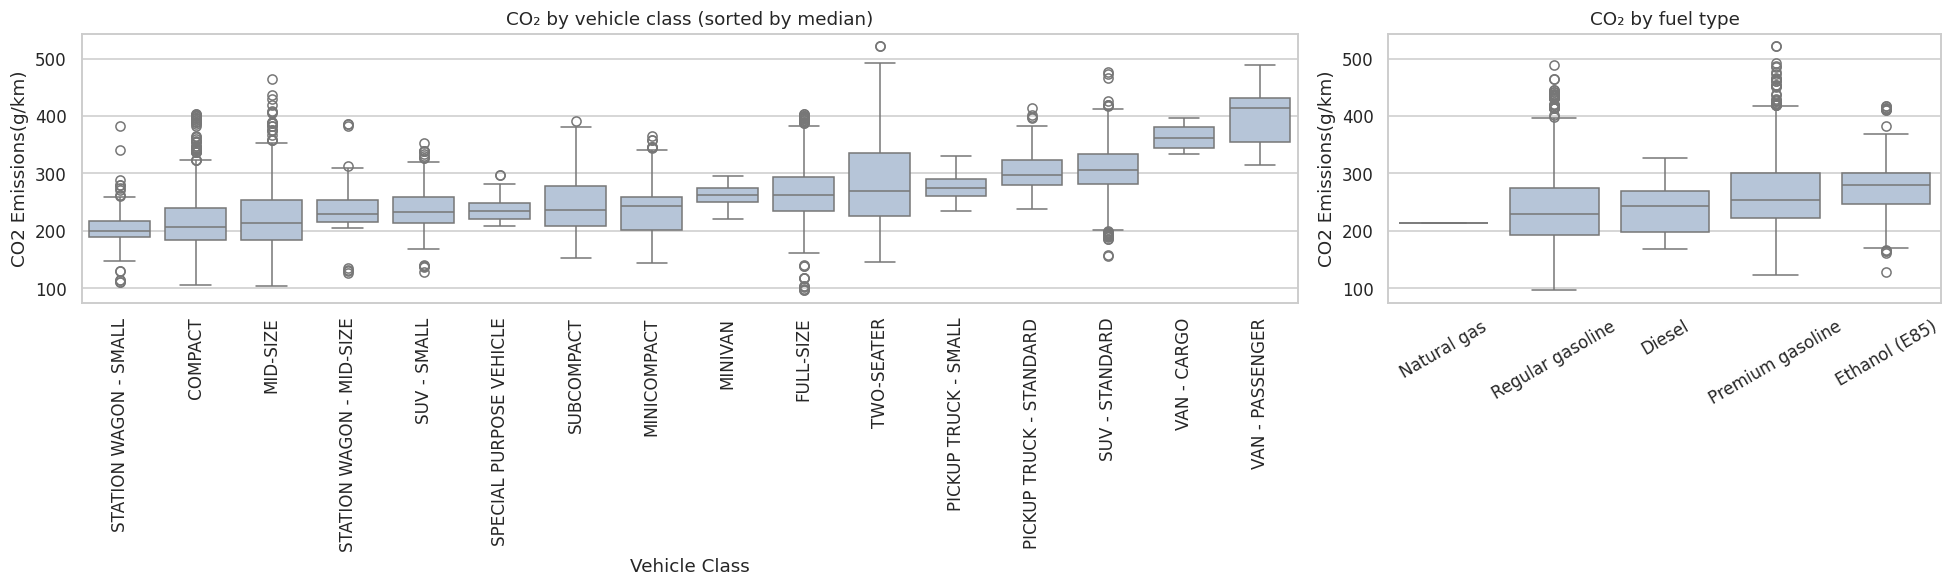

,Vehicles,Mean_CO2,Mean_Engine_L,Mean_Cylinders,Mean_Comb_L100
Fuel Name,,,,,
Natural gas,1,213.00,3.60,6.00,12.70
Diesel,147,235.24,2.53,4.93,8.75
Regular gasoline,3039,235.98,2.84,5.04,10.13
Premium gasoline,2765,265.73,3.44,6.18,11.41
Ethanol (E85),330,276.05,4.14,6.56,16.93


In [ ]:
class_order = eda.groupby("Vehicle Class")[TARGET].median().sort_values().index
eda["Fuel Name"] = eda["Fuel Type"].map(FUEL_TYPES)
fuel_order = eda.groupby("Fuel Name")[TARGET].median().sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5), gridspec_kw={"width_ratios": [2.2, 1]})
sns.boxplot(data=eda, x="Vehicle Class", y=TARGET, order=class_order, ax=axes[0], color="lightsteelblue")
axes[0].tick_params(axis="x", rotation=90); axes[0].set_title("CO₂ by vehicle class (sorted by median)")
sns.boxplot(data=eda, x="Fuel Name", y=TARGET, order=fuel_order, ax=axes[1], color="lightsteelblue")
axes[1].tick_params(axis="x", rotation=30); axes[1].set_title("CO₂ by fuel type"); axes[1].set_xlabel("")
plt.tight_layout(); plt.show()

# Is the fuel-type gap a property of the fuel, or of the vehicles that use it?
fuel_summary = (eda.groupby("Fuel Name")
                .agg(Vehicles=(TARGET, "size"), Mean_CO2=(TARGET, "mean"),
                     Mean_Engine_L=("Engine Size(L)", "mean"), Mean_Cylinders=("Cylinders", "mean"),
                     Mean_Comb_L100=(COMB, "mean"))
                .sort_values("Mean_CO2").round(2))
display(fuel_summary)

**Observation — Q5.**
- **Vehicle class:** medians and spreads differ clearly — small/compact and two-seater-type classes sit at the low end, while large SUVs, vans and pickup trucks sit at the high end. Classes overlap, so class alone cannot predict emissions, but it adds information beyond engine size.
- **Fuel type** (X = regular, Z = premium, D = diesel, E = E85, N = natural gas): some categories sit systematically higher or lower.
- **Confounding caution.** The summary table shows that fuel types are used by *different kinds of vehicles* (different average engine size, cylinders and consumption). For example, premium gasoline is typical of larger, higher-performance engines. A raw gap between fuel types therefore mixes a fuel effect with a vehicle-mix effect. Only the regression, which holds engine and consumption constant, can separate them (the model interpretation section).
- Some fuel categories have very few vehicles (see `Vehicles`), so conclusions about them are less reliable.

### 4.5 Unusually high or low emitters (Q6)

In [ ]:
show_cols = ["Make", "Model", "Vehicle Class", "Engine Size(L)", "Cylinders", "Fuel Type", COMB, TARGET]
high = eda.sort_values(TARGET, ascending=False).head(10)
low = eda.sort_values(TARGET).head(10)
print("10 highest-emission vehicles (de-duplicated):"); display(high[show_cols])
print("10 lowest-emission vehicles (de-duplicated):");  display(low[show_cols])
print(f"Average CO₂ — highest 10: {high[TARGET].mean():.1f} g/km | lowest 10: {low[TARGET].mean():.1f} g/km")

# Unusual *relative to similar vehicles*: z-score within peer groups
peer = ["Vehicle Class", "Cylinders", "Fuel Type"]
g = eda.groupby(peer)[TARGET]
eda["Peer_n"] = g.transform("size")
eda["Peer_z"] = (eda[TARGET] - g.transform("mean")) / g.transform("std")
peers_ok = eda[(eda["Peer_n"] >= 10) & eda["Peer_z"].notna()]
print("\nHigher-than-peers (same class, cylinders and fuel type):")
display(peers_ok.sort_values("Peer_z", ascending=False).head(6)[show_cols + ["Peer_z"]].round(2))
print("Lower-than-peers:")
display(peers_ok.sort_values("Peer_z").head(6)[show_cols + ["Peer_z"]].round(2))

10 highest-emission vehicles (de-duplicated):


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
4199,BUGATTI,CHIRON,TWO-SEATER,8.0,16,Z,22.2,522
4897,BUGATTI,Chiron,TWO-SEATER,8.0,16,Z,22.2,522
5329,LAMBORGHINI,Aventador Roadster,TWO-SEATER,6.5,12,Z,21.7,493
349,FORD,E350 WAGON,VAN - PASSENGER,6.8,10,X,21.2,488
5328,LAMBORGHINI,Aventador Coupe,TWO-SEATER,6.5,12,Z,21.5,487
6119,LAMBORGHINI,Aventador Coupe,TWO-SEATER,6.5,12,Z,21.4,485
2762,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,Z,21.4,476
4583,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,Z,20.3,473
3788,MERCEDES-BENZ,AMG G 65,SUV - STANDARD,6.0,12,Z,20.3,467
4834,BENTLEY,Mulsanne,MID-SIZE,6.8,8,Z,20.0,465


10 lowest-emission vehicles (de-duplicated):


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km)
5228,HYUNDAI,IONIQ Blue,FULL-SIZE,1.6,4,X,4.1,96
3581,HYUNDAI,IONIQ BLUE,FULL-SIZE,1.6,4,X,4.1,96
6062,HYUNDAI,IONIQ,FULL-SIZE,1.6,4,X,4.2,99
4450,HYUNDAI,IONIQ,FULL-SIZE,1.6,4,X,4.3,102
3580,HYUNDAI,IONIQ,FULL-SIZE,1.6,4,X,4.4,103
3019,TOYOTA,PRIUS,MID-SIZE,1.8,4,X,4.5,104
5227,HYUNDAI,IONIQ,FULL-SIZE,1.6,4,X,4.3,104
4025,TOYOTA,PRIUS,MID-SIZE,1.8,4,X,4.5,105
4741,TOYOTA,PRIUS,MID-SIZE,1.8,4,X,4.5,105
5692,TOYOTA,Prius,MID-SIZE,1.8,4,X,4.4,105


Average CO₂ — highest 10: 487.8 g/km | lowest 10: 101.9 g/km

Higher-than-peers (same class, cylinders and fuel type):


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km),Peer_z
4834,BENTLEY,Mulsanne,MID-SIZE,6.8,8,Z,20.0,465,3.99
959,SUBARU,IMPREZA WAGON AWD,STATION WAGON - SMALL,2.5,4,Z,12.5,288,3.88
5924,CHEVROLET,Silverado 4WD Custom Trail Boss,PICKUP TRUCK - STANDARD,6.2,8,Z,15.2,357,3.65
3467,FORD,GT,TWO-SEATER,3.5,6,Z,17.3,406,3.38
5944,DODGE,Charger SRT Hellcat Widebody,FULL-SIZE,6.2,8,Z,15.6,368,3.36
4376,FORD,GT,TWO-SEATER,3.5,6,Z,17.1,403,3.31


Lower-than-peers:


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Fuel Type,Fuel Consumption Comb (L/100 km),CO2 Emissions(g/km),Peer_z
3817,MERCEDES-BENZ,GLA 250 4MATIC,SUV - SMALL,2.0,4,E,12.0,128,-3.97
6244,TOYOTA,Corolla Hybrid,COMPACT,1.8,4,X,4.5,106,-3.74
5954,FORD,Escape Hybrid,SUV - SMALL,2.5,4,X,5.8,136,-3.71
993,TOYOTA,PRIUS c,COMPACT,1.5,4,X,4.7,108,-3.64
5955,FORD,Escape Hybrid AWD,SUV - SMALL,2.5,4,X,5.9,139,-3.58
6254,TOYOTA,RAV4 Hybrid AWD,SUV - SMALL,2.5,4,X,6.0,139,-3.58


**Observation — Q6.**
- The highest emitters are large-displacement, high-cylinder vehicles with very high fuel consumption; the lowest emitters are small-engine vehicles with low consumption. The gap between the two groups (see the printed averages) confirms very different emission profiles.
- These extremes are largely **explained** by engine size, cylinders and consumption, i.e. they are genuine, not errors.
- The peer-group z-scores identify vehicles that deviate from *comparable* vehicles (same class, cylinders and fuel). Typical explanations are differences in engine tuning, weight, aerodynamics, transmission or turbocharging, which the dataset does not record. This is descriptive only and does not establish causation.
- The model-based residual analysis in Q9 error analysis revisits this question with the fitted model.

---
## 5. Feature Engineering & Pre-Modelling (Q7)

### 5.1 Feature-selection decisions

| Feature | Decision | Reason |
|---|---|---|
| Engine Size, Cylinders | Keep (numeric) | Strong relationship with CO₂ (Q3 correlation analysis, Q4 visual analysis) |
| Fuel Consumption Comb (L/100 km) | Keep in **Model B only** | Strongest predictor, but nearly a second reading of the target |
| Fuel Consumption City / Hwy / Comb (mpg) | **Drop** | Severe multicollinearity (VIF, Q3 multicollinearity analysis) |
| Vehicle Class, Transmission, Fuel Type | Keep (one-hot encoded) | Low cardinality, interpretable |
| Make, Model | Drop from the model (used for diagnostics only) | 42 and 2,053 levels to high-dimensional, sparse, hard to interpret |

### 5.2 Encoding, scaling and pipeline
- **Categorical to one-hot encoding**, because a linear model needs numeric inputs and the categories have no natural order. `handle_unknown="ignore"` prevents failures on unseen categories.
- **Numeric to standardisation (`StandardScaler`)**: ordinary linear regression is unaffected by scale, but Ridge/Lasso penalties depend on coefficient size, and standardised coefficients are directly comparable across features.
- Everything sits inside a single **`Pipeline`**, so scaling and encoding are learned from the training folds only — no data leakage in cross-validation.

In [ ]:
model_data = cars_no_duplicates.copy()

NUM_SPEC = ["Engine Size(L)", "Cylinders"]
NUM_FULL = NUM_SPEC + [COMB]
CAT = ["Vehicle Class", "Transmission", "Fuel Type"]

SCENARIOS = {
    "Model A: Specification-only":            (NUM_SPEC, CAT),
    "Model B: Specification + Consumption":   (NUM_FULL, CAT),
}

X = model_data[NUM_FULL + CAT]
y = model_data[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

# Descriptive columns kept aside for residual diagnostics only (never fed to the model)
meta_test = model_data.loc[X_test.index, ["Make", "Model", "Vehicle Class", "Engine Size(L)",
                                          "Cylinders", "Fuel Type", COMB]]

def make_pipeline(num_cols, cat_cols, regressor):
    prep = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])
    return Pipeline([("prep", prep), ("reg", regressor)])

print("Rows for modelling :", len(model_data))
print("Training / test    :", len(X_train), "/", len(X_test))
print("Encoded features   : Model A =", make_pipeline(NUM_SPEC, CAT, LinearRegression()).fit(X_train[NUM_SPEC + CAT], y_train)
      .named_steps["prep"].get_feature_names_out().shape[0],
      "| Model B =", make_pipeline(NUM_FULL, CAT, LinearRegression()).fit(X_train[NUM_FULL + CAT], y_train)
      .named_steps["prep"].get_feature_names_out().shape[0])

Rows for modelling : 6282
Training / test    : 5025 / 1257
Encoded features   : Model A = 49 | Model B = 50


### Observation — Q7
- After removing exact duplicates, **6,282 rows** are available; 80 % train / 20 % test with a fixed seed (42). The test set is untouched until final evaluation.
- The encoded design matrices have a few dozen columns — modest for 6,282 rows, so overfitting is not a major concern, and a linear model remains fully interpretable.
- Because engine size, cylinders and consumption are still correlated, and one-hot dummies of the same variable are linearly dependent, **regularized models (Ridge, Lasso)** are compared with ordinary linear regression in the next section.

---
## 6. Model Building (Q8)

### 6.1 Modelling approach
- **Why linear models?** The council needs *interpretable* levers; coefficients read directly as "g/km per unit of feature". The EDA also showed roughly linear relationships.
- **Ridge (L2)** shrinks correlated coefficients together and handles residual multicollinearity. **Lasso (L1)** can additionally zero-out unhelpful features.
- The regularization strength `alpha` is tuned with **5-fold cross-validation** (`GridSearchCV`) on the training set only.
- Both scenarios (A and B) are modelled, and the algorithm with the lowest cross-validated RMSE is *selected* for each.

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

CANDIDATES = {
    "OLS":   (LinearRegression(), None),
    "Ridge": (Ridge(),            {"reg__alpha": np.logspace(-3, 3, 13)}),
    "Lasso": (Lasso(max_iter=50000), {"reg__alpha": np.logspace(-4, 1, 11)}),
}

def evaluate(model, cols):
    pred = model.predict(X_test[cols])
    r2 = r2_score(y_test, pred)
    n = len(y_test)
    p = model.named_steps["prep"].transform(X_test[cols]).shape[1]
    return pred, {"Test MAE": mean_absolute_error(y_test, pred),
                  "Test RMSE": np.sqrt(mean_squared_error(y_test, pred)),
                  "Test R²": r2,
                  "Test Adj R²": 1 - (1 - r2) * (n - 1) / (n - p - 1)}

fitted, rows = {}, []
for scen, (nums, cats) in SCENARIOS.items():
    cols = nums + cats
    for name, (est, grid) in CANDIDATES.items():
        pipe = make_pipeline(nums, cats, clone(est))
        if grid:
            search = GridSearchCV(pipe, grid, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
            search.fit(X_train[cols], y_train)
            model, alpha = search.best_estimator_, search.best_params_["reg__alpha"]
        else:
            model, alpha = pipe.fit(X_train[cols], y_train), np.nan

        # Cross-validated performance of the chosen configuration (training data only)
        cvres = cross_validate(clone(model), X_train[cols], y_train, cv=cv,
                               scoring=["r2", "neg_root_mean_squared_error"])
        pred, m = evaluate(model, cols)
        fitted[(scen, name)] = {"model": model, "cols": cols, "pred": pred}
        rows.append({"Scenario": scen, "Algorithm": name, "Best alpha": alpha,
                     "CV RMSE (mean)": -cvres["test_neg_root_mean_squared_error"].mean(),
                     "CV RMSE (std)": cvres["test_neg_root_mean_squared_error"].std(),
                     "CV R² (mean)": cvres["test_r2"].mean(), "CV R² (std)": cvres["test_r2"].std(), **m})

results = pd.DataFrame(rows)
selected = results.loc[results.groupby("Scenario")["CV RMSE (mean)"].idxmin()]
results["Selected"] = results.index.isin(selected.index)
print("Selected per scenario (lowest CV RMSE):")
display(selected[["Scenario", "Algorithm", "Best alpha", "CV RMSE (mean)"]].round(4))

Selected per scenario (lowest CV RMSE):


,Scenario,Algorithm,Best alpha,CV RMSE (mean)
2,Model A: Specification-only,Lasso,0.0001,22.6425
4,Model B: Specification + Consumption,Ridge,0.3162,5.2810


### Observation — Q8
- A **linear regression model** was selected because the case study requires an interpretable estimate of CO₂ emissions and an explanation of how vehicle characteristics relate to emissions.
- **Model A — Specification-only** uses Engine Size, Cylinders, Vehicle Class, Transmission and Fuel Type. It represents an early-stage estimate when measured fuel consumption is not yet available.
- **Model B — Specification + Fuel Consumption** adds Combined Fuel Consumption (L/100 km). It represents the situation where a measured efficiency value is available.
- Categorical variables are one-hot encoded and numerical variables are standardized within the preprocessing pipeline.
- The linear model can be understood conceptually as `CO₂ = intercept + β₁(feature₁) + β₂(feature₂) + ...`, where the learned coefficients represent the model's estimated relationship between the predictors and CO₂ emissions.
- Ridge and Lasso are also compared with ordinary linear regression using cross-validation.

### 6.2 What does the model learn? Coefficients and feature importance (Q3 follow-up)

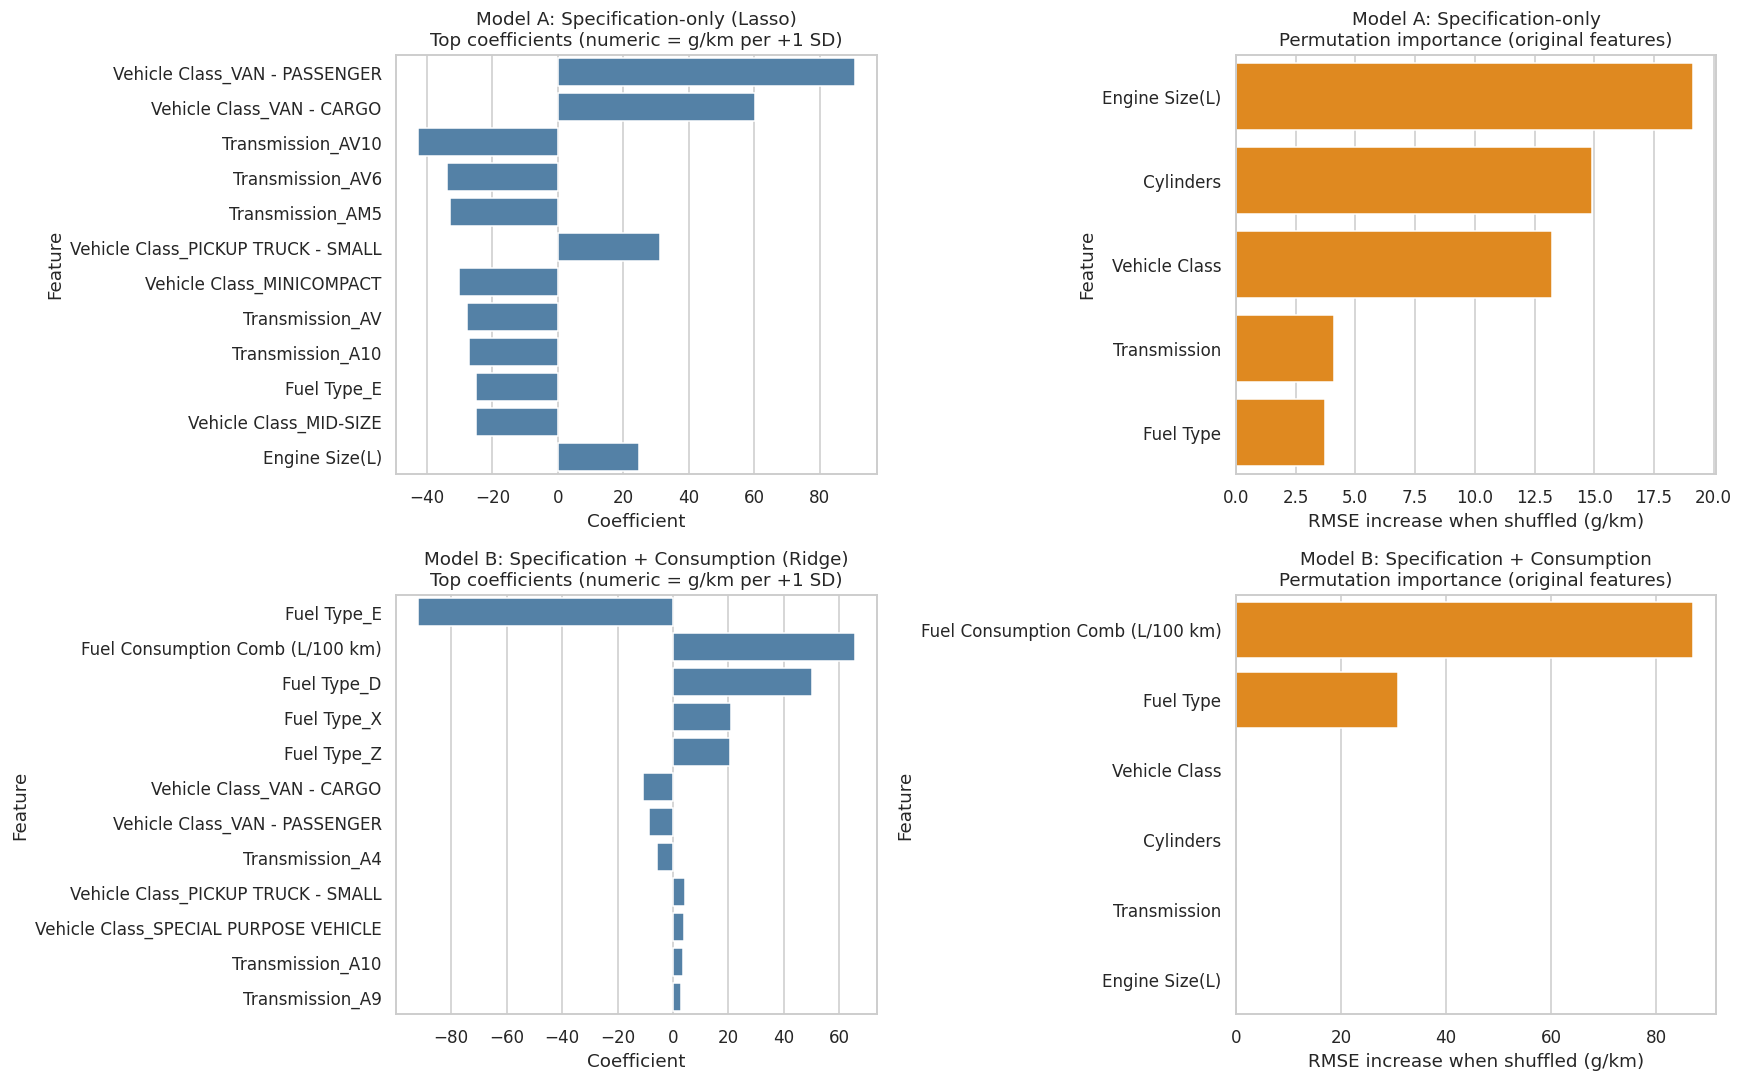

Model A: Specification-only


,Feature,RMSE increase when shuffled (g/km)
0,Engine Size(L),19.16
1,Cylinders,14.92
2,Vehicle Class,13.23
3,Transmission,4.09
4,Fuel Type,3.73


Model B: Specification + Consumption


,Feature,RMSE increase when shuffled (g/km)
0,Fuel Consumption Comb (L/100 km),87.13
1,Fuel Type,30.86
2,Vehicle Class,0.21
3,Cylinders,0.17
4,Transmission,0.14
5,Engine Size(L),0.02


Correlation vs model importance (numeric features):


,|corr with CO₂|,Model A permutation importance,Model B permutation importance
Engine Size(L),0.855,19.157,0.019
Cylinders,0.835,14.920,0.173
Fuel Consumption Comb (L/100 km),0.917,NaN,87.129


In [ ]:
def coef_table(model):
    names = model.named_steps["prep"].get_feature_names_out()
    names = [n.replace("num__", "").replace("cat__", "") for n in names]
    return (pd.DataFrame({"Feature": names, "Coefficient": model.named_steps["reg"].coef_})
            .assign(Abs=lambda d: d["Coefficient"].abs()).sort_values("Abs", ascending=False)
            .drop(columns="Abs").reset_index(drop=True))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
imp_tables = {}
for row, (scen, sel) in enumerate(selected.set_index("Scenario")["Algorithm"].items()):
    f = fitted[(scen, sel)]
    ct = coef_table(f["model"]).head(12)
    sns.barplot(data=ct, y="Feature", x="Coefficient", ax=axes[row, 0], color="steelblue")
    axes[row, 0].set_title(f"{scen} ({sel})\nTop coefficients (numeric = g/km per +1 SD)")

    pi = permutation_importance(f["model"], X_test[f["cols"]], y_test, n_repeats=10,
                                random_state=RANDOM_STATE, scoring="neg_root_mean_squared_error")
    imp = (pd.DataFrame({"Feature": f["cols"], "RMSE increase when shuffled (g/km)": pi.importances_mean})
           .sort_values("RMSE increase when shuffled (g/km)", ascending=False))
    imp_tables[scen] = imp
    sns.barplot(data=imp, y="Feature", x="RMSE increase when shuffled (g/km)", ax=axes[row, 1], color="darkorange")
    axes[row, 1].set_title(f"{scen}\nPermutation importance (original features)")
plt.tight_layout(); plt.show()

for scen, imp in imp_tables.items():
    print(scen); display(imp.round(2).reset_index(drop=True))

# Do correlation and model importance agree?
cmp = pd.DataFrame({"|corr with CO₂|": corr[TARGET].abs().reindex(NUM_FULL)})
for scen, imp in imp_tables.items():
    cmp[scen.split(":")[0] + " permutation importance"] = imp.set_index("Feature")["RMSE increase when shuffled (g/km)"].reindex(NUM_FULL)
print("Correlation vs model importance (numeric features):"); display(cmp.round(3))

### Observation
- **Numeric coefficients are per one standard deviation**, so their sizes are directly comparable. Categorical coefficients are shifts relative to the average vehicle.
- **Model A:** engine size and cylinders dominate the numeric drivers; vehicle class and fuel type add further, smaller adjustments.
- **Model B:** combined fuel consumption dominates the permutation importance by a wide margin, and once it is present the importance of engine size and cylinders drops sharply — their information is already contained in the consumption figure. This is the reverse of what the raw correlations (where engine size looked important on its own) suggest, and it illustrates why correlation ranking alone can mislead when predictors are related.
- **Fuel type still matters in Model B** even after controlling for consumption. Consumption is measured in *litres*, and fuels differ in carbon content and energy per litre, so the same L/100 km produces different grams of CO₂ for, say, diesel versus gasoline or ethanol. This separates the genuine fuel effect from the vehicle-mix effect noticed in Q5 comparison analysis.

---
## 7. Model Evaluation & Interpretation (Q9)

### 7.1 Metrics
| Metric | What it tells us |
|---|---|
| **MAE** | Average absolute error in g/km — the typical miss, easy to explain. |
| **RMSE** | Like MAE but squares errors first, so **large misses are penalised more**. RMSE much greater than MAE signals occasional big errors. |
| **R²** | Share of the variance in CO₂ explained by the model (1 = perfect). |
| **Adjusted R²** | R² penalised for the number of encoded predictors — checks that the fit is not simply due to adding features. |
| **CV mean ± std** | Performance across 5 training folds. A small std and close agreement with the test score indicates the model generalises and is not overfitting one split. |

In [ ]:
table = results[["Scenario", "Algorithm", "Best alpha", "CV RMSE (mean)", "CV RMSE (std)",
                 "CV R² (mean)", "CV R² (std)", "Test MAE", "Test RMSE", "Test R²", "Test Adj R²", "Selected"]]
display(table.round(4).style.apply(lambda r: ["background-color: #e8f4ea" if r["Selected"] else "" for _ in r], axis=1))

,Scenario,Algorithm,Best alpha,CV RMSE (mean),CV RMSE (std),CV R² (mean),CV R² (std),Test MAE,Test RMSE,Test R²,Test Adj R²,Selected
0,Model A: Specification-only,OLS,nan,22.644600,0.556700,0.852100,0.012100,17.287400,22.517300,0.859500,0.853800,False
1,Model A: Specification-only,Ridge,0.316200,22.644500,0.557100,0.852200,0.012100,17.290200,22.517600,0.859500,0.853800,False
2,Model A: Specification-only,Lasso,0.000100,22.642500,0.557900,0.852200,0.012100,17.293300,22.527200,0.859400,0.853700,True
3,Model B: Specification + Consumption,OLS,nan,5.281400,0.472000,0.991900,0.001700,3.301000,6.006400,0.990000,0.989600,False
4,Model B: Specification + Consumption,Ridge,0.316200,5.281000,0.472200,0.991900,0.001700,3.304900,5.997900,0.990000,0.989600,True
5,Model B: Specification + Consumption,Lasso,0.000300,5.281100,0.472700,0.991900,0.001700,3.317600,6.196500,0.989400,0.988900,False


### Observation — Q9
- **Model A — Specification-only:** MAE **17.29 g/km**, RMSE **22.52 g/km**, R² **0.8595**, Adjusted R² **0.8538**.
- **Model B — Specification + Fuel Consumption:** MAE **3.30 g/km**, RMSE **6.01 g/km**, R² **0.9900**, Adjusted R² **0.9896**.
- For Model A, an MAE of 17.29 g/km means that the typical absolute difference between the predicted and actual CO₂ value is about 17.29 g/km.
- Model A's R² of 0.8595 means that approximately **85.95% of the variation in CO₂ emissions in the test data is explained by the model's included vehicle characteristics**.
- Adding combined fuel consumption substantially reduces prediction error. Model B's R² of 0.9900 means that approximately **99% of the variation in the test data is explained by the model**.
- RMSE is higher than MAE because RMSE gives greater weight to larger prediction errors.
- The close values of R² and Adjusted R² indicate that the fit is not simply explained by the number of encoded predictors.
- Model B's very high performance should be interpreted as a strong **predictive/conversion relationship** because fuel consumption and CO₂ are closely related measurements. It should not be interpreted as proof that fuel consumption alone causally determines emissions.
- Cross-validation and residual diagnostics are used to check whether the observed performance is stable rather than dependent on one train/test split.

### 7.2 Predicted vs actual and residual diagnostics

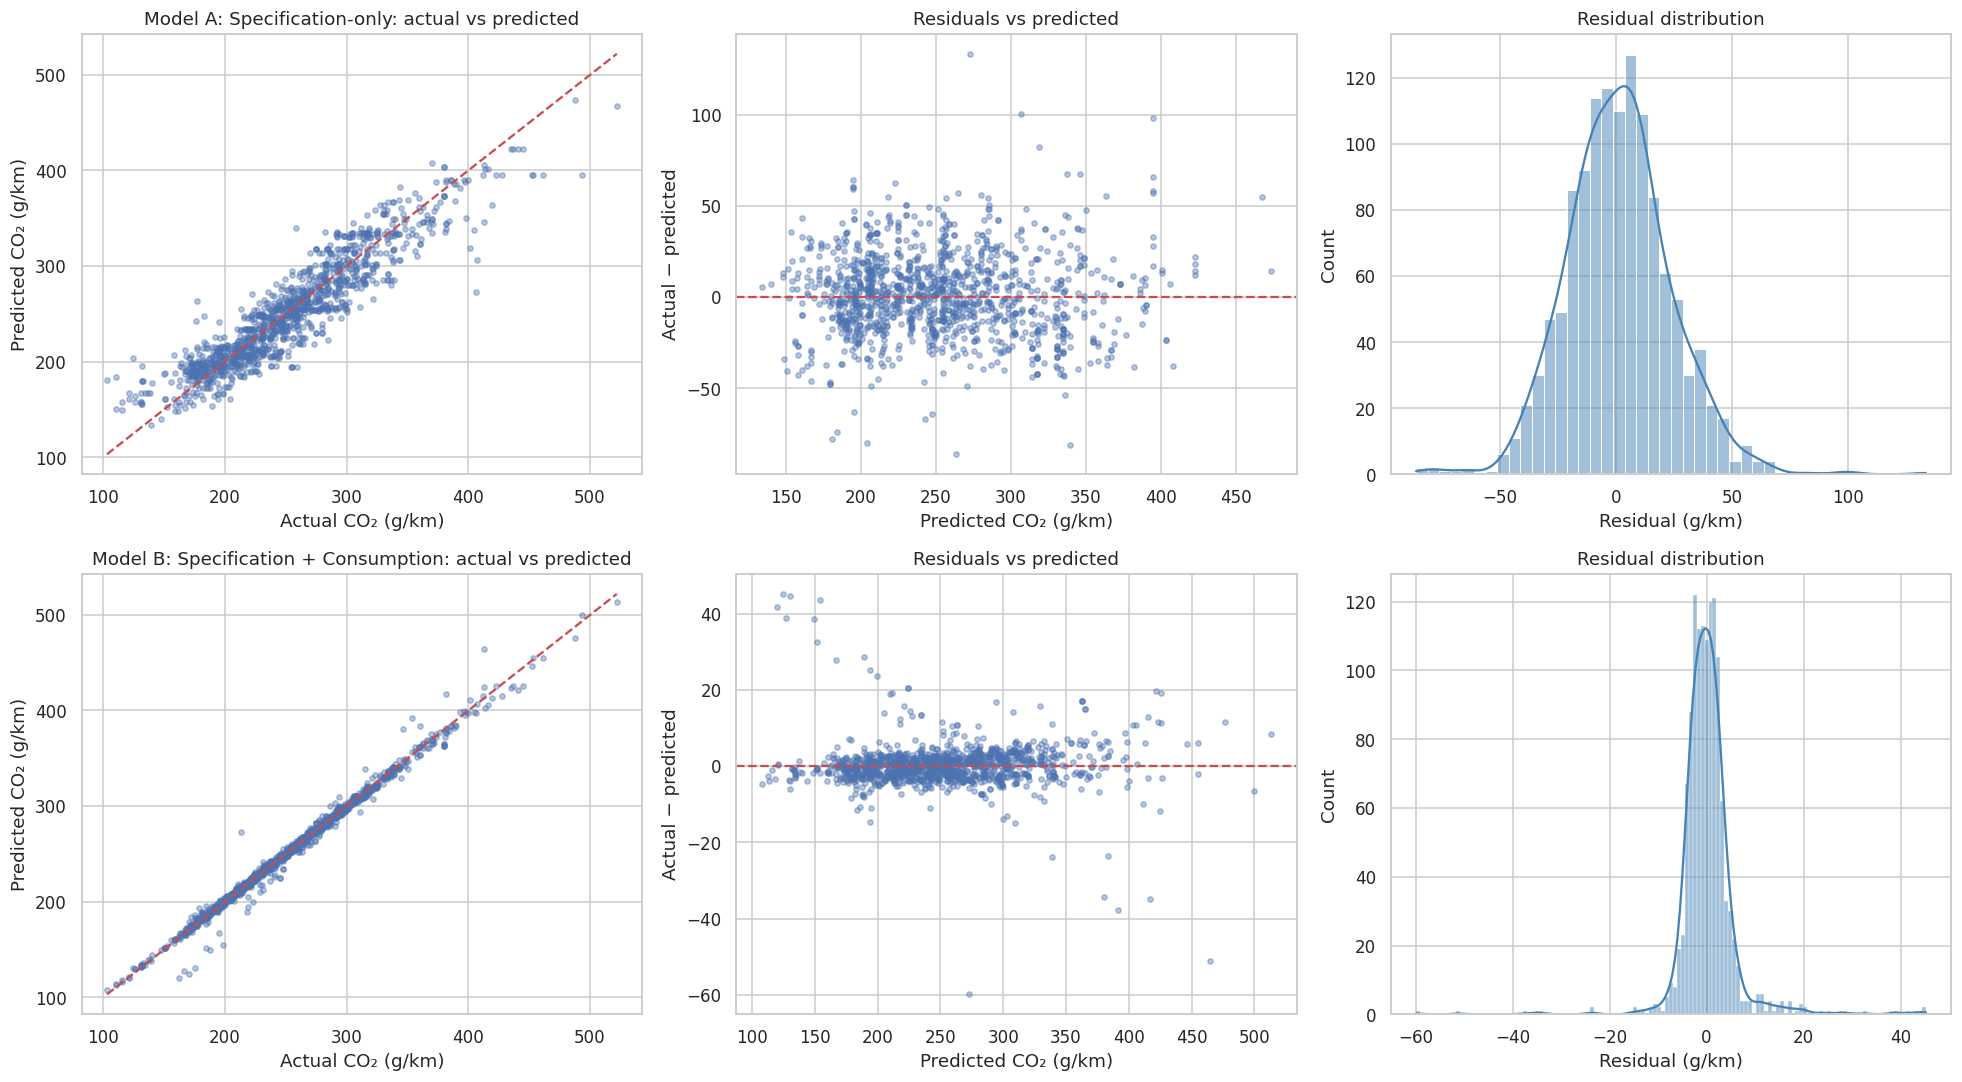

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, (scen, sel) in enumerate(selected.set_index("Scenario")["Algorithm"].items()):
    pred = fitted[(scen, sel)]["pred"]
    resid = y_test - pred
    lim = [y_test.min(), y_test.max()]
    axes[row, 0].scatter(y_test, pred, alpha=0.4, s=12)
    axes[row, 0].plot(lim, lim, "r--"); axes[row, 0].set_title(f"{scen}: actual vs predicted")
    axes[row, 0].set_xlabel("Actual CO₂ (g/km)"); axes[row, 0].set_ylabel("Predicted CO₂ (g/km)")
    axes[row, 1].scatter(pred, resid, alpha=0.4, s=12)
    axes[row, 1].axhline(0, color="r", ls="--"); axes[row, 1].set_title("Residuals vs predicted")
    axes[row, 1].set_xlabel("Predicted CO₂ (g/km)"); axes[row, 1].set_ylabel("Actual − predicted")
    sns.histplot(resid, kde=True, ax=axes[row, 2], color="steelblue")
    axes[row, 2].set_title("Residual distribution"); axes[row, 2].set_xlabel("Residual (g/km)")
plt.tight_layout(); plt.show()

### Observation — Q9.2
- **Model B:** points hug the diagonal across the whole range; residuals are small and centred on zero.
- **Model A:** more scatter, and it is worth checking the extremes — a systematic bend (under-prediction of the highest emitters, over-prediction of the lowest) would indicate a mild non-linearity that a linear model cannot capture.
- A funnel shape in the residual-vs-predicted plot would indicate errors that grow with emission level; a roughly bell-shaped, centred histogram supports leaving the target untransformed (Section 3.4).

### 7.3 Where does the model fail? Largest errors (Section 5.4 of the brief)

In [ ]:
worst_cols = ["Make", "Model", "Vehicle Class", "Engine Size(L)", "Cylinders", "Fuel Type",
              "Actual", "Predicted", "Residual"]
resid_frames = {}
for scen, sel in selected.set_index("Scenario")["Algorithm"].items():
    df = meta_test.copy()
    df["Actual"], df["Predicted"] = y_test, fitted[(scen, sel)]["pred"]
    df["Residual"] = df["Actual"] - df["Predicted"]
    df["AbsError"] = df["Residual"].abs()
    resid_frames[scen] = df
    print(f"\n{scen} — 10 largest errors")
    display(df.sort_values("AbsError", ascending=False).head(10)[worst_cols].round(1))
    print("MAE by fuel type:");    display(df.groupby("Fuel Type")["AbsError"].agg(["size", "mean"]).round(2).rename(columns={"size": "n", "mean": "MAE"}))
    print("MAE by vehicle class (largest 6):")
    display(df.groupby("Vehicle Class")["AbsError"].agg(["size", "mean"]).round(2).rename(columns={"size": "n", "mean": "MAE"})
            .sort_values("MAE", ascending=False).head(6))


Model A: Specification-only — 10 largest errors


,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Fuel Type,Actual,Predicted,Residual
3467,FORD,GT,TWO-SEATER,3.5,6,Z,406,272.6,133.4
50,AUDI,R8 SPYDER,TWO-SEATER,4.2,8,Z,407,306.6,100.4
5329,LAMBORGHINI,Aventador Roadster,TWO-SEATER,6.5,12,Z,493,394.9,98.1
1075,ACURA,RLX HYBRID,MID-SIZE,3.5,6,Z,177,263.2,-86.2
3815,MERCEDES-BENZ,G 550,SUV - STANDARD,4.0,8,Z,401,318.5,82.5
196,CHEVROLET,CORVETTE,TWO-SEATER,6.2,8,Z,258,339.3,-81.3
1047,VOLKSWAGEN,JETTA TURBO HYBRID,COMPACT,1.4,4,Z,124,204.1,-80.1
3580,HYUNDAI,IONIQ,FULL-SIZE,1.6,4,X,103,181.0,-78.0
3684,KIA,NIRO FE,STATION WAGON - SMALL,1.6,4,X,110,184.1,-74.1
4141,BENTLEY,MULSANNE,MID-SIZE,6.8,8,Z,405,337.4,67.6


MAE by fuel type:


,n,MAE
Fuel Type,,
D,42,13.77
E,68,17.10
N,1,41.62
X,589,16.59
Z,557,18.28


MAE by vehicle class (largest 6):


...

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Fuel Type,Actual,Predicted,Residual
2232,CHEVROLET,IMPALA DUAL FUEL,MID-SIZE,3.6,6,N,213,272.9,-59.9
228,CHEVROLET,EXPRESS 3500 PASSENGER,VAN - PASSENGER,6.0,8,E,413,464.2,-51.2
2405,FORD,FOCUS FFV,COMPACT,2.0,4,E,170,124.8,45.2
2407,FORD,FOCUS FFV,COMPACT,2.0,4,E,175,130.3,44.7
2781,MERCEDES-BENZ,CLA 250 4MATIC FFV,COMPACT,2.0,4,E,198,154.5,43.5
408,FORD,FOCUS SFE FFV,COMPACT,2.0,4,E,162,120.3,41.7
1411,FORD,FOCUS FFV,COMPACT,2.0,4,E,166,127.0,39.0
3458,FORD,FOCUS FFV,COMPACT,2.0,4,E,188,149.5,38.5
476,GMC,YUKON DENALI XL AWD,SUV - STANDARD,6.2,8,E,354,391.7,-37.7
351,FORD,E350 WAGON FFV,VAN - PASSENGER,5.4,8,E,382,416.8,-34.8


MAE by fuel type:


,n,MAE
Fuel Type,,
D,42,5.59
E,68,14.87
N,1,59.90
X,589,2.51
Z,557,2.46


MAE by vehicle class (largest 6):


,n,MAE
Vehicle Class,,
VAN - PASSENGER,12,18.91
VAN - CARGO,4,18.73
SUV - STANDARD,126,4.12
COMPACT,190,3.78
SPECIAL PURPOSE VEHICLE,10,3.78
FULL-SIZE,109,3.57


### Observation — Q9.3
- The largest errors are the vehicles the model finds hardest: check whether they cluster in **rare fuel types** (small `n`, so the model has little evidence), in **extreme engine sizes / high cylinder counts**, or in **special vehicle classes** — the grouped MAE tables show this directly.
- In Model A, big misses reflect what specifications *cannot* see: weight, turbocharging, tuning, aerodynamics and driving efficiency. Model B removes most of these errors because fuel consumption already reflects them.
- These edge cases mark where the linear assumptions break down and where the council should be cautious about applying the model — for instance to unusual fuel types or ultra-high-performance vehicles.

## 8. Business Insights & Recommendations (Q10)

### 8.1 Factors associated with CO₂ emissions

The analysis identifies several important factors. They should be interpreted as **associated/predictive factors rather than independent causal rankings**, because several vehicle characteristics are strongly related to one another.

| Factor | Evidence from the analysis | Interpretation |
|---|---|---|
| **Fuel consumption (L/100 km)** | Strongest numerical correlation with CO₂ (about **0.92**) and dominant permutation importance in Model B | Higher fuel consumption is strongly associated with higher CO₂ emissions per kilometre. |
| **Engine size** | Strong positive correlation and an important numeric driver in Model A | Larger engines are generally associated with higher emissions in this dataset. |
| **Cylinder count** | Strong positive correlation and an important numeric driver in Model A | Higher cylinder counts are generally associated with higher-emission vehicle configurations. |
| **Vehicle class** | Clear differences in CO₂ distributions across classes | Vehicle class captures differences between vehicle configurations and their typical emission profiles. |
| **Fuel type** | Differences remain relevant after accounting for consumption | Fuel type provides additional information because fuels can differ in CO₂ produced per litre consumed. |
| **Transmission** | Smaller contribution than the factors above | Transmission provides a secondary adjustment in the model. |

### 8.2 Supporting emission-reduction analysis

1. **Improve fuel efficiency.** Because fuel consumption has the strongest relationship with CO₂ in this dataset, reducing fuel consumption is directly associated with lower emissions per kilometre.
2. **Consider engine efficiency and design.** Engine size and cylinder count are important predictors in the specification-only model and can therefore be considered during early vehicle-design analysis.
3. **Consider vehicle class in fleet analysis.** Different vehicle classes have different emission profiles, so fleet composition can be analysed alongside individual vehicle efficiency.
4. **Account for fuel type explicitly.** Equal L/100 km values do not necessarily imply identical CO₂ emissions across fuels, so fuel type should remain part of comparative analysis.
5. **Use the two models for different stages.** Model A provides an early estimate when only specifications are available; Model B provides a more accurate estimate when measured fuel consumption is available.
6. **Investigate the high-emission tail.** Extreme-emission vehicles can be examined separately to identify configurations that warrant further investigation.

### 8.3 Limitations and next steps

- The analysis demonstrates **association and prediction, not causation**.
- Vehicle mass, aerodynamics, turbocharging, hybridisation and real-world driving conditions are not included in the dataset.
- Rare fuel types have fewer observations, so estimates for those groups may be less stable.
- Additional variables and non-linear models could be investigated if the objective is to improve the specification-only model.

### 8.4 Final conclusion

A specification-based linear regression provides an interpretable baseline for estimating vehicle CO₂ emissions. The specification-only model achieves a test **MAE of 17.29 g/km and R² of 0.8595**, showing that vehicle specifications explain a substantial share of the observed variation. Adding combined fuel consumption reduces the MAE to **3.30 g/km** and increases test **R² to 0.9900**, demonstrating the very strong predictive relationship between measured fuel consumption and CO₂ emissions.

Overall, the analysis identifies **fuel consumption, engine size and cylinder count**, together with **vehicle class and fuel type**, as important factors associated with CO₂ emissions. These findings can support efficiency and vehicle-design analysis, while the limitations of the available variables should be considered before using the model for broader policy or real-world emission decisions.
